# Astra finalists + external candidates vs heuristic_v1

Seeds 1-3 comparison of Astra's finalist controllers (Dispersal, Refuge, Decoy) and the
`original-eat-rest-overcrowding-v4` candidate against our `heuristic_v1`. All scores below
come from real full headless games (`SimulationCore`, seed, `starting_predators=0`, run to
extinction or the 3000s time limit) via `external/finalists/run_external.py` and
`external/candidates/run_candidate.py` -- not any candidate's own decision-check suite.
(`original-eat-rest-overcrowding-v4`'s own `validation.json` ships `full_simulations_run: 0`;
its 9 checks are policy-state comparisons against the baseline, not survival scores.)

Seeds 20-39 (unseen-seed generalization) will be added here once that run finishes.


In [1]:
import glob
import os

import pandas as pd

CSV_NAMES = ["EXTERNAL_seeds1-3.csv", "EXTERNAL_original-eat-rest-overcrowding-v4_seeds1-3.csv"]


def load(csv_name):
    path = os.path.join("results", csv_name)
    if not os.path.isfile(path):
        candidates = glob.glob(os.path.join("**", csv_name), recursive=True)
        if not candidates:
            raise FileNotFoundError(f"{csv_name} not found -- run this notebook from survival-simulator/")
        path = candidates[0]
    return pd.read_csv(path)


df = pd.concat([load(name) for name in CSV_NAMES], ignore_index=True)
df.loc[df["agent"] == "original_eat_rest_overcrowding_v4", "agent"] = "v4"
df.pivot(index="seed", columns="agent", values="score")


agent,decoy,dispersal,refuge,v1,v4
seed,,,,,
1,1086.5943,1647.1724,1655.0775,1098.1027,1623.4001
2,1695.6335,1233.9275,1295.9935,1004.6450,1511.4337
3,1700.4594,1493.8118,1807.3065,1074.6105,1463.8696


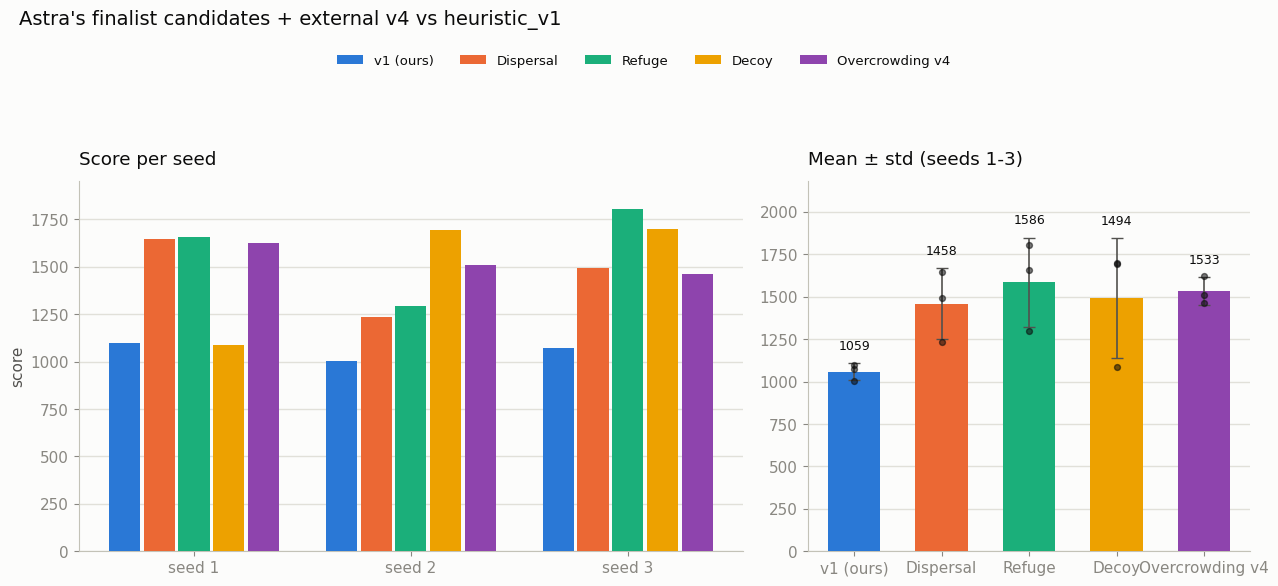

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

AGENT_ORDER = ["v1", "dispersal", "refuge", "decoy", "v4"]
LABELS = {"v1": "v1 (ours)", "dispersal": "Dispersal", "refuge": "Refuge", "decoy": "Decoy",
          "v4": "Overcrowding v4"}
COLORS = {"v1": "#2a78d6", "dispersal": "#eb6834", "refuge": "#1baf7a", "decoy": "#eda100",
          "v4": "#8e44ad"}

SURFACE, INK, INK_2, MUTED, GRID, BASELINE = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7",
)
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_2, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 11,
})

seeds = sorted(df["seed"].unique())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [3, 2]})

# Left: score per seed, grouped by agent. Exact values are in the pivot table above,
# so bars carry the pattern here rather than repeating every number (avoids label
# collisions between near-tied bars, e.g. seed 1's dispersal/refuge).
n = len(AGENT_ORDER)
bar_w = 0.8 / n
y_top = df["score"].max()
handles = []
for i, agent in enumerate(AGENT_ORDER):
    sub = df[df["agent"] == agent].set_index("seed")
    vals = [sub.loc[s, "score"] if s in sub.index else 0 for s in seeds]
    xs = [xi + (i - (n - 1) / 2) * bar_w for xi in range(len(seeds))]
    bars = ax1.bar(xs, vals, width=bar_w * 0.9, color=COLORS[agent], label=LABELS[agent], zorder=3)
    handles.append(bars)
ax1.set_ylim(top=y_top * 1.08)
ax1.set_xticks(range(len(seeds)))
ax1.set_xticklabels([f"seed {s}" for s in seeds])
ax1.set_ylabel("score")
ax1.set_title("Score per seed", loc="left", pad=12)
ax1.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax1.set_axisbelow(True)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Right: mean +/- std per agent, with per-seed dots
means = [df[df["agent"] == a]["score"].mean() for a in AGENT_ORDER]
stds = [df[df["agent"] == a]["score"].std() for a in AGENT_ORDER]
ax2.bar(range(n), means, width=0.6, color=[COLORS[a] for a in AGENT_ORDER], zorder=3,
        yerr=stds, error_kw=dict(ecolor=INK_2, elinewidth=1.2, capsize=4, zorder=4))
for i, agent in enumerate(AGENT_ORDER):
    pts = df[df["agent"] == agent]["score"].values
    ax2.scatter([i] * len(pts), pts, color=INK, s=18, zorder=5, alpha=0.55)
for i, m in enumerate(means):
    ax2.text(i, m + stds[i] + max(means) * 0.04, f"{m:.0f}", ha="center", va="bottom", fontsize=9, color=INK)
ax2.set_ylim(top=(max(m + s for m, s in zip(means, stds))) * 1.18)
ax2.set_xticks(range(n))
ax2.set_xticklabels([LABELS[a] for a in AGENT_ORDER])
ax2.set_title("Mean \u00b1 std (seeds 1-3)", loc="left", pad=12)
ax2.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle("Astra's finalist candidates + external v4 vs heuristic_v1", fontsize=14, x=0.02, ha="left", y=1.06)
fig.legend(handles=[h[0] for h in handles], labels=[LABELS[a] for a in AGENT_ORDER],
           loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=5, frameon=False, fontsize=9.5)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
plt.show()
